In [3]:
import qutip as q
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import (AutoMinorLocator)
import numpy as np
import schemdraw
import schemdraw.elements as elm
%matplotlib inline

In [8]:
def plot_energy_as_function(x, energies, unit="Hz", y_range=False, Ej=None, x_axis="", E01=None, levels = 2):

    fig, ax = plt.subplots(1,3, figsize=(18,6))

    if (Ej):
        ax[0].plot(x, -Ej * np.cos(x), label="Potential of the JJ")
        energies = energies
    for i in range(len(energies[0])): # for each energy level, plot its curve
        ax[0].plot(x, energies[:, i], zorder=3)
    ax[0].set_ylabel(rf'Energies/$\hbar$ ({unit})', fontsize=14)
    ax[0].set_xlabel(rf"{x_axis} (levels) | $\phi$ (potential)" if Ej else x_axis, fontsize=14)
    ax[0].grid(linestyle='-', linewidth=1)
    ax[0].set_ylim(y_range if y_range else (energies[len(energies[:,0])//2][0]-0.5, energies[len(energies[:,3])//2][3]+0.5))
    for i in range(len(energies[0])):
        ax[0].annotate(fr"$|{i}\rangle$", xy=(0.3, energies[len(energies[:,i])//2][i]))
    ax[0].yaxis.set_minor_locator(AutoMinorLocator())

    k = 1
    if E01:
        k = 2
        for i in range(len(energies[0])):
            ax[1].plot(x, energies[:,i]/E01, zorder=3)
        ax[1].set_ylabel(r'Energies ($E_n/E_{01}$)', fontsize=14)
        ax[1].set_xlabel(x_axis, fontsize=14)
        ax[1].grid(linestyle='-', linewidth=1)
        ax[1].set_ylim(y_range if y_range else (energies[len(energies[:,0])//2][0]/E01-0.5, energies[len(energies[:,2])//2][2]/E01+0.5))
        for i in range(len(energies[0])):
            ax[1].annotate(fr"$|{i}\rangle$", xy=(0.3, energies[len(energies[:,i])//2][i]/E01))
        ax[1].yaxis.set_minor_locator(AutoMinorLocator())
        ax[1].legend()
    else: ax[2].set_visible(False)
    
    diffs = np.array([(np.delete(energies[i], 0) - np.delete(energies[i], len(energies[i])-1)) for i in range(len(energies[:,0]))])
    for i in range(levels):
        ax[k].plot(x, diffs[:,i], zorder=3, label=fr"$|{i}\rangle\rightarrow|{i+1}\rangle$")
    ax[k].set_ylabel(rf'Energy Differences/$\hbar$ ({unit})', fontsize=14)
    ax[k].set_xlabel(x_axis, fontsize=14)
    ax[k].grid(linestyle='-', linewidth=1)
    for i in range(levels):
        ax[k].annotate(fr"$|{i}\rangle$ to $|{i+1}\rangle$", xy=(0, diffs[len(diffs[:,i])//2][i]))
    ax[k].yaxis.set_minor_locator(AutoMinorLocator())
    ax[k].legend()
    
    return fig, ax

## Superconducting Qubits 2
### Transmon Qubit Dynamics

Now that we've examined a variety of the many superconducting circuits which can be used to implement a qubit, let's take a deeper look at how these circuits actually behave. For this exercise, we will use the transmon circuit below, operating in the transmon regime ($E_J>>E_c$).

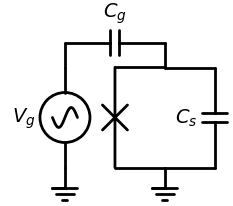

In [9]:
with schemdraw.Drawing() as d:
    d.config(unit=2)
    elm.Ground()
    elm.SourceSin().up().label(r"$V_g$")
    elm.Line().up().length(0.5)
    elm.Capacitor().right().label(r"$C_g$")
    elm.Line().down().length(0.5)
    elm.Line().right(1)
    elm.Capacitor().down().label(r"$C_s$")
    elm.Line().left().length(1)
    elm.Ground()
    elm.Line().left().length(1)
    elm.Josephson().up()
    elm.Line().right().length(1)

In [4]:
def transmon_ng(Ec, Ej, ng, N):
    H = 4 * Ec * ((q.charge(N)-ng)**2).full() + 0.5 * Ej * (np.diag(-np.ones(2*N), 1) + np.diag(-np.ones(2*N), -1))

    return q.Qobj(H)

To refresh ourselves, let's examine the energy levels this Hamiltonian yields.

In [5]:
Ec = 0.3 # 300 MHz
Ej = 7 # 7 GHz
all_ng = np.linspace(-4, 4, 200)
N = 10

energies = np.array([transmon_ng(Ec, Ej, ng, N).eigenenergies() for ng in all_ng])
plot_energy_as_function(all_ng, energies, unit="GHz", x_axis=r"$n_g$", E01=energies[112][1]-energies[112][0])

NameError: name 'plot_energy_as_function' is not defined

In this transmon regime, we don't have the worry about offset gate charge affecting our energy levels. Note this is a design choice for this exercise! We could just as well engineer a qubit outside the transmon regime and operate at the "sweet spot" of $n_g=0.5$.

In [8]:
Ec = 0.3 # 300 MHz
Ej = 7 # 7 GHz
ng = 0.5 # Choosing 0.5 but in the transmon regime can be anything
N = 10

H = transmon_ng(Ec, Ej, ng, N)
print(H)

Quantum object: dims=[[21], [21]], shape=(21, 21), type='oper', dtype=Dense, isherm=True
Qobj data =
[[132.3  -3.5   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    0.    0. ]
 [ -3.5 108.3  -3.5   0.    0.    0.    0.    0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    0.    0. ]
 [  0.   -3.5  86.7  -3.5   0.    0.    0.    0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    0.    0. ]
 [  0.    0.   -3.5  67.5  -3.5   0.    0.    0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    0.    0. ]
 [  0.    0.    0.   -3.5  50.7  -3.5   0.    0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    0.    0. ]
 [  0.    0.    0.    0.   -3.5  36.3  -3.5   0.    0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    0.    0. ]
 [  0.    0.    0.    0.    0.   -3.5  24.3  -3.5   0.    0.    0.    0.
    0.    0.    0.    0.    0.    0.    0.    

Using the code below, we can extract the energy levels (eigenenergies).

In [24]:
eigenergies, eigfuncs = H.eigenstates()
print(eigenergies)
print(f"Lowest levels energy gap: {eigenergies[1]-eigenergies[0]}")

[ -5.02869178  -1.25897467   2.15439124   4.86155607   8.16427597
   8.68014071  15.13125187  15.13848391  24.55705589  24.55707714
  36.47066974  36.47066976  50.82171782  50.82171804  67.59122529
  67.59127035  86.77095414  86.77774155 108.36175779 108.86031713
 132.80539205]
Lowest levels energy gap: 3.769717113877104


We will use the lowest two states as our ground and excited state. We see the gap between them is about 3.77 GHz; this is the resonant frequency of our system and the frequency required to excite the ground state. To find the Rabi frequency, $\Omega$, of our system, we can

Text(0.5, 0, 't')

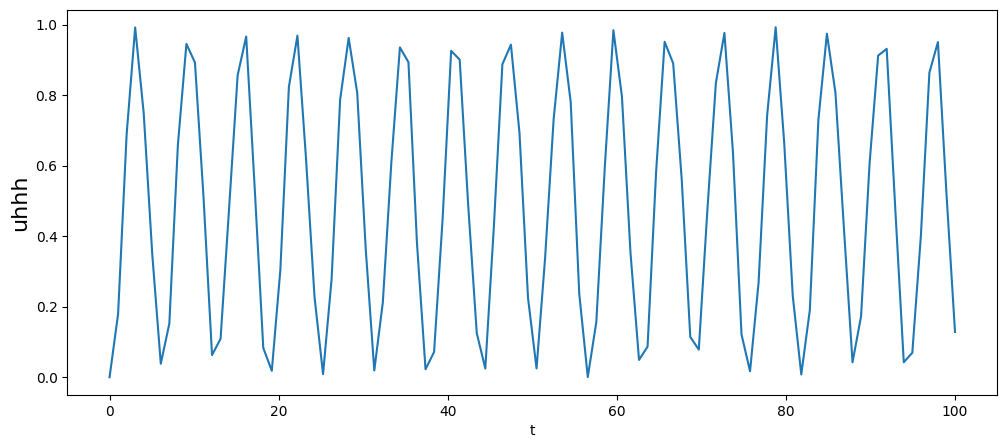

In [42]:
g = eigfuncs[0]
e = eigfuncs[1]
t = np.linspace(0, 100, 100)

sz = g * g.dag() - e * e.dag()
sx = g * e.dag() + e * g.dag()

H0 = 0.5 * (eigenergies[1]-eigenergies[0]) * sz
Hd = 1 * sx
d=0
args = {'wd': (eigenergies[1]-eigenergies[0]+d)}

result = q.mesolve([H0, [Hd, 'sin(wd*t)']], g, t, [], [q.ket2dm(e)], args=args)


fig, ax = plt.subplots(figsize=(12,5))

ax.plot(result.times, result.expect[0])

ax.set_ylabel("uhhh", fontsize=16)
ax.set_xlabel("t")

C:\Users\ANNA STEEN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


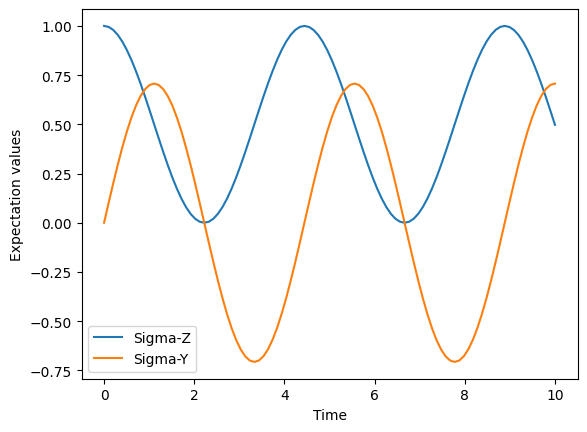

In [ ]:
g = ekets[0]
e = ekets[1]

# GOAL: translate these ground/excited states into the 2 level approximation, then visualize!

H = - 0.5 * q.sigmaz() - 0.5 * q.sigmax()
psi0 = q.basis(2, 0)
times = np.linspace(0.0, 10.0, 100)

result = q.mesolve(H, psi0, times, [], [q.sigmaz(), q.sigmay()])

fig, ax = plt.subplots()

ax.plot(result.times, result.expect[0])
ax.plot(result.times, result.expect[1])
ax.set_xlabel('Time')
ax.set_ylabel('Expectation values')
ax.legend(("Sigma-Z", "Sigma-Y"))
plt.show()

In [ ]:
def simple_transmon(Ec, Ej):
    H = - Ec * 0.5 * q.sigmaz() - Ej * 0.5 * q.sigmax()
    
    return q.Qobj(H)

https://qutip.org/docs/4.2/guide/dynamics/dynamics-master.html
https://phas.ubc.ca/~berciu/TEACHING/PHYS502/PROJECTS/20-JC-AA.pdf
https://docs.google.com/presentation/d/1weOSrVPw7hNnEL_e_v6rwj1OUdVaBbFU/edit?slide=id.p30#slide=id.p30